In [137]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../Codes/library/')

from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/antigen_presentation/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


In [138]:
def simulate_exact(alpha, k_on, sigma, lam, lam_B, delta, x0, T=None, T_peak=None, Theta=None, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    div = []
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break #comment to create complete trajectories even after division threshold reached

         # --- event 1: birth clock (NHPP) ---
        if t < T_peak:
            r = rng.exponential(1.0)
            tau_b = (1.0/lam) * np.log(1.0 + (lam/(k_on*alpha**sigma))*r*np.exp(-lam*t))
        else:
            tau_b = np.inf

        # --- event 2: death clock ---
        if n > 0:
            tau_d = rng.exponential(1.0/(delta*n)) # mean = 1/(delta*n)
        else:
            tau_d = np.inf

        # --- event 3: "B" event (halving) ---
        if (Theta is not None) and (n > Theta) and (lam_B > 0.0):
            tau_B = rng.exponential(1.0 / (lam_B))  # mean = 1/lam_B
        else:
            tau_B = np.inf

        # choose which event happens next
        if tau_b <= tau_d and tau_b <= tau_B:
            t += tau_b
            n += 1
        elif tau_d <= tau_b and tau_d <= tau_B:
            t += tau_d
            n -= 1
        else:
            t += tau_B
            n //= 2   # integer halving; use n = n / 2 for float halving
            div.append(t/6)  # record division time if Theta used

        # if tau_b < tau_d:
        #     t += tau_b
        #     n += 1
        # else:
        #     t += tau_d
        #     n -= 1

        traj.append((t/6, n))

    return traj, div  # also return division time if Theta used

In [139]:
def simulate_tauleap(alpha, lam, delta, x0, T=None, Theta=None,
                     eps=0.05, eta=0.2, dt_max=np.inf, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        dt1 = (1.0/lam) * np.log(1.0 + eps)         # control exp-growth change
        dt2 = eta / delta                            # control death fraction
        dt  = min(dt1, dt2, dt_max)

        # don't step past the end time
        if T is not None:
            dt = min(dt, T - t)
            if dt <= 0: break

        # births: Poisson with integrated intensity
        m_b = (alpha/lam) * (np.exp(lam*(t+dt)) - np.exp(lam*t))
        B = rng.poisson(m_b)

        # deaths: Binomial (nonnegative guarantee)
        p = 1.0 - np.exp(-delta*dt)
        D = rng.binomial(n, p) if n > 0 else 0

        n = n + B - D
        t = t + dt
        traj.append((t, n))

    return traj

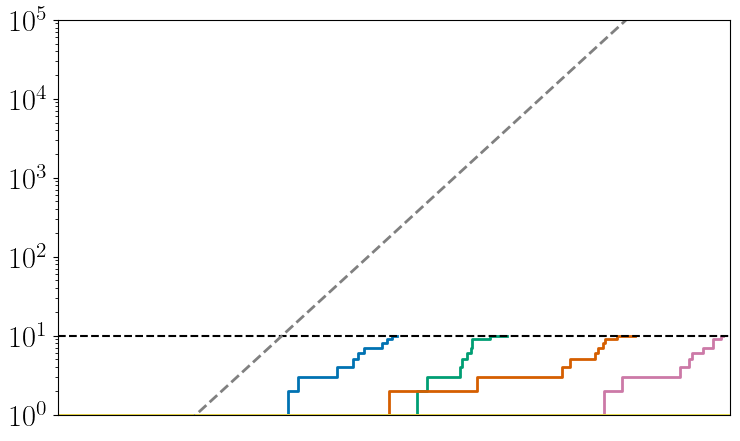

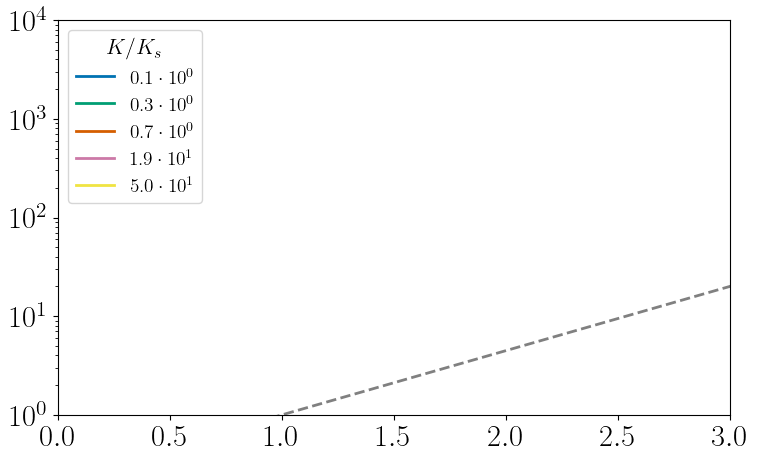

In [ ]:
beta = 2.2
lam_B = 0.25
sigmas = [1.0, 3.0]
Thetas = [10., 1.0]
T = 18
T_peak = 18
k_on = 1e-3
times = np.linspace(0, T, 100)
Ks = np.logspace(0.01, 1.7, 5)
data_simulation = defaultdict(list)
trajectories = []
for Theta in Thetas:
    for sigma in sigmas:
        for i_ens in range(100):
            for K, omega in zip(Ks, Ks**beta):
                ts_act = []
                for n in range(int(omega)):
                    traj1, div = simulate_exact(alpha=1/K, k_on = k_on, sigma = sigma, lam=1, lam_B = lam_B, delta=0.01, x0=0, T=T, T_peak = T_peak, Theta=Theta)
                    t_act = max((item[0] for item in traj1 if item[1] <= Theta))
                    ts_act.append(t_act)
                    # traj2 = simulate_tauleap(alpha=alpha, lam=1, delta=0.01, x0=0, T=20, Theta=theta)
                data_simulation['beta'].append(beta)
                data_simulation['sigma'].append(sigma)
                data_simulation['theta'].append(Theta)
                data_simulation['K'].append(K)
                data_simulation['N0'].append(omega)
                data_simulation['t_act_mean'].append(np.mean(ts_act))
                data_simulation['t_act_min'].append(np.min(ts_act))
                if i_ens == 0 and sigma == sigmas[-1] and Theta == Thetas[0]:
                    trajectories.append((traj1, div, K))
                    ax_pi.step(*zip(*traj1), lw = 2, label = r'$%.1f \times 10^{%.1e}$'%(K/10, np.log10(K)))
                    # ax_cs.plot(times[times>t_act], np.exp(lam_B*(times[times>t_act] - t_act)), lw = 2, label = r'$%.1e$'%K)
                    ax_cs.step(div, 2**np.arange(len(div)), lw = 2, label = r'$%.1f \cdot 10^{%d}$'%(K/10, np.log10(K)))

print(trajectories)


In [ ]:
plt.style.use("seaborn-v0_8-colorblind")
fig_pi, ax_pi = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
fig_cs, ax_cs = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})

for i in range(len(trajectories)):
    trajectories.append((traj1, div, K))
    ax_pi.step(*zip(*traj1), lw = 2, label = r'$%.1f \times 10^{%.1e}$'%(K/10, np.log10(K)))
    # ax_cs.plot(times[times>t_act], np.exp(lam_B*(times[times>t_act] - t_act)), lw = 2, label = r'$%.1e$'%K)
    ax_cs.step(div, 2**np.arange(len(div)), lw = 2, label = r'$%.1f \cdot 10^{%d}$'%(K/10, np.log10(K)))

ax_pi.hlines(Thetas[0], 0, T, colors='k', linestyles='dashed')
ax_pi.plot(times/6, np.exp(times-6)*Thetas[0], color = 'grey', ls = '--', lw = 2)
ax_cs.plot(times/6, np.exp(lam_B*(times-6)), color = 'grey', ls = '--', lw = 2)
data_simulation_df = pd.DataFrame(data_simulation)
result = (
    data_simulation_df.groupby(["sigma", "theta", "K", 'N0'])[["t_act_mean", "t_act_min"]]
    .mean()
    .reset_index()
)
# my_plot_layout(ax=ax_pi, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
# ax.set_yscale('log')
ax_pi.set_ylim(bottom=0.99, top = 10000.2*Thetas[0])
ax_pi.set_xlim(left=0, right=T/6)
ax_pi.tick_params(axis='both', which='major', labelsize=22)
# ax_pi.legend(loc = 2, fontsize = 14, title = r'$K$', title_fontsize = 16)
fig_pi.savefig(output_plot + 'trajectories.pdf')
ax_pi.set_yscale('log')
ax_pi.set_xticks([])
fig_pi.savefig(output_plot + 'trajectories_log.pdf')


# my_plot_layout(ax=ax_cs, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_cs.set_yscale('log')
ax_cs.set_ylim(bottom=0.99, top = 1e4)
ax_cs.set_xlim(left=0, right=T/6)
ax_cs.tick_params(axis='both', which='major', labelsize=22)
ax_cs.legend(loc = 2, fontsize = 14, title = r'$K/K_s$', title_fontsize = 16)
fig_cs.savefig(output_plot + 'clone-sizes.pdf')

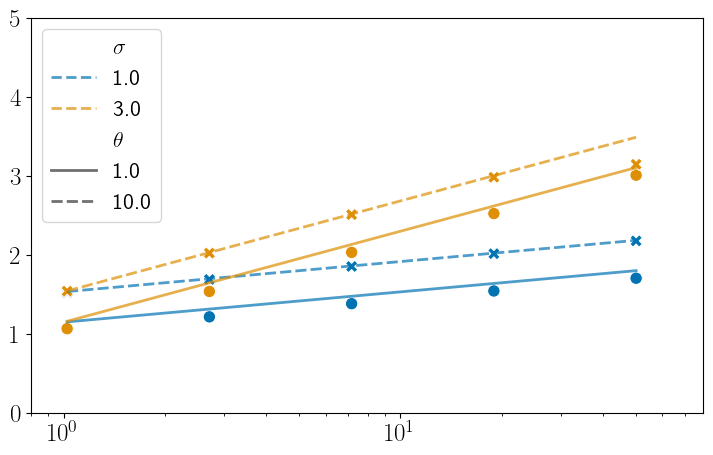

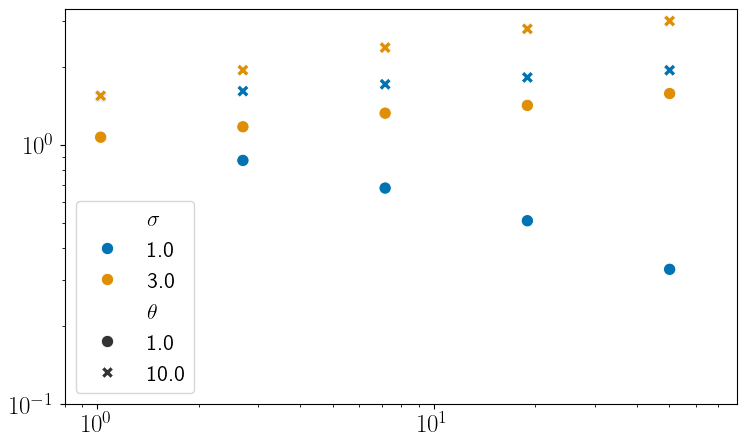

In [136]:
fig_mean, ax_mean = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
result['t_act_mean_theory'] = (np.log(1/k_on) + result['sigma']*np.log(result['K']) + np.log(result['theta']))/6
sns.scatterplot(data = result, x = 'K', y = 't_act_mean', hue = 'sigma', style = 'theta', ax=ax_mean, legend=False, palette='colorblind', s=80)
sns.lineplot(data = result, x = 'K', y = 't_act_mean_theory', hue = 'sigma', style = 'theta', ax=ax_mean, legend=True, linestyle='--', palette='colorblind', lw = 2, alpha = 0.7)
# my_plot_layout(ax=ax_mean, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_mean.set_xscale('log')
# ax_mean.set_yscale('log')
ax_mean.tick_params(axis='both', which='major', labelsize=18)
ax_mean.set_ylim(bottom=0, top = 30/6)
ax_mean.set_xlim(left=0.8, right=10**1.9)
ax_mean.legend(loc = 2, fontsize = 14)
handles, labels = ax_mean.get_legend_handles_labels()
ax_mean.legend_.remove()
# manually modify labels list
labels[0] = r"$\sigma$"
# find where the second section starts
n_hue = result["sigma"].nunique()
labels[n_hue + 1] = r"$\theta$"
# rebuild
ax_mean.legend(
    handles,
    labels,
    fontsize = 16
)
ax_mean.set(xlabel=None, ylabel=None)
fig_mean.savefig(output_plot + 'times_mean.pdf')

fig_min, ax_min = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
sns.scatterplot(data = result, x = 'K', y = 't_act_min', hue = 'sigma', style = 'theta', ax=ax_min, legend=True, palette='colorblind', s=80)
# sns.lineplot(data = result, x = 'K', y = 't_act_mean_theory', hue = 'sigma', style = 'theta', ax=ax_min, legend=True, linestyle='--')
# my_plot_layout(ax=ax_min, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_min.set_xscale('log')
ax_min.set_yscale('log')
ax_min.tick_params(axis='both', which='major', labelsize=18)
ax_min.set_ylim(bottom=1e-1, top = 20/6)
ax_min.set_xlim(left=0.8, right=10**1.9)
ax_min.legend(loc = 3, fontsize = 14)
handles, labels = ax_min.get_legend_handles_labels()
ax_min.legend_.remove()
# manually modify labels list
labels[0] = r"$\sigma$"
# find where the second section starts
n_hue = result["sigma"].nunique()
labels[n_hue + 1] = r"$\theta$"
# rebuild
ax_min.legend(
    handles,
    labels,
    fontsize = 16
)
ax_min.set(xlabel=None, ylabel=None)
fig_min.savefig(output_plot + 'times_min.pdf')
